# 🔄 Retention Analysis

**Goal:** Measure how many customers return after their first purchase, and understand *why* they don't.

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

## Load Clean Data
96,478 delivered orders from the cleaning step.

In [121]:
DATA_DIR = Path('../data')
orders_clean = pd.read_csv(DATA_DIR / 'orders_clean.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date'])

In [122]:
orders_clean.shape

(96478, 12)

In [123]:
first_purchase = orders_clean.groupby('customer_unique_id')['order_purchase_timestamp'].min()

## Building Cohort Matrix
Grouping customers by their first purchase month, then tracking how many return in subsequent months.

In [124]:
first_purchase = first_purchase.reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']
first_purchase['cohort'] = first_purchase['first_purchase_date'].dt.to_period('M')

In [125]:
# print(first_purchase)

In [126]:
orders_clean = pd.merge(orders_clean,first_purchase, on='customer_unique_id', how='left')

In [127]:
# orders_clean.head()
# orders_clean.shape
# orders_clean.loc[orders_clean['cohort'].isna()]

In [128]:
orders_clean['order_period'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')

In [129]:
orders_clean['month_since_first'] = (orders_clean['order_period'] - orders_clean['cohort']).apply(lambda x: x.n)

In [130]:
# orders_clean.head()

In [131]:
cohort_data = orders_clean.groupby(['cohort','month_since_first'])['customer_unique_id'].nunique()

In [132]:
cohort_matrix = cohort_data.unstack()

## Retention Rate (% of cohort returning)

In [133]:
cohort_matrix_pct = cohort_matrix.div(cohort_matrix[0], axis=0) * 100
cohort_matrix_pct = cohort_matrix_pct.round(1)

In [134]:
print(cohort_matrix_pct)

month_since_first     0      1    2    3    4    5    6    7    8    9    10  \
cohort                                                                         
2016-09            100.0    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10            100.0    NaN  NaN  NaN  NaN  NaN  0.4  NaN  NaN  0.4  NaN   
2016-12            100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01            100.0    0.3  0.3  0.1  0.4  0.1  0.4  0.1  0.1  NaN  0.4   
2017-02            100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2  0.1  0.2  0.1   
2017-03            100.0    0.4  0.4  0.4  0.4  0.2  0.2  0.3  0.3  0.1  0.4   
2017-04            100.0    0.6  0.2  0.2  0.3  0.3  0.4  0.3  0.3  0.2  0.3   
2017-05            100.0    0.5  0.5  0.3  0.3  0.3  0.4  0.1  0.3  0.3  0.3   
2017-06            100.0    0.5  0.4  0.4  0.3  0.4  0.4  0.2  0.1  0.2  0.3   
2017-07            100.0    0.5  0.3  0.2  0.3  0.2  0.3  0.1  0.2  0.3  0.2   
2017-08            100.0    0.7  0.3  0.

## Spot Check: January 2017 Cohort
717 customers acquired → only 2 returned the next month → **0.28% retention**

In [135]:
print(cohort_matrix.loc['2017-01', 0])

print(cohort_matrix.loc['2017-01', 1])

print(cohort_matrix.loc['2017-01', 1] / cohort_matrix.loc['2017-01', 0] * 100)

717.0
2.0
0.2789400278940028


## Cohort Retention Heatmap

<Axes: xlabel='month_since_first', ylabel='cohort'>

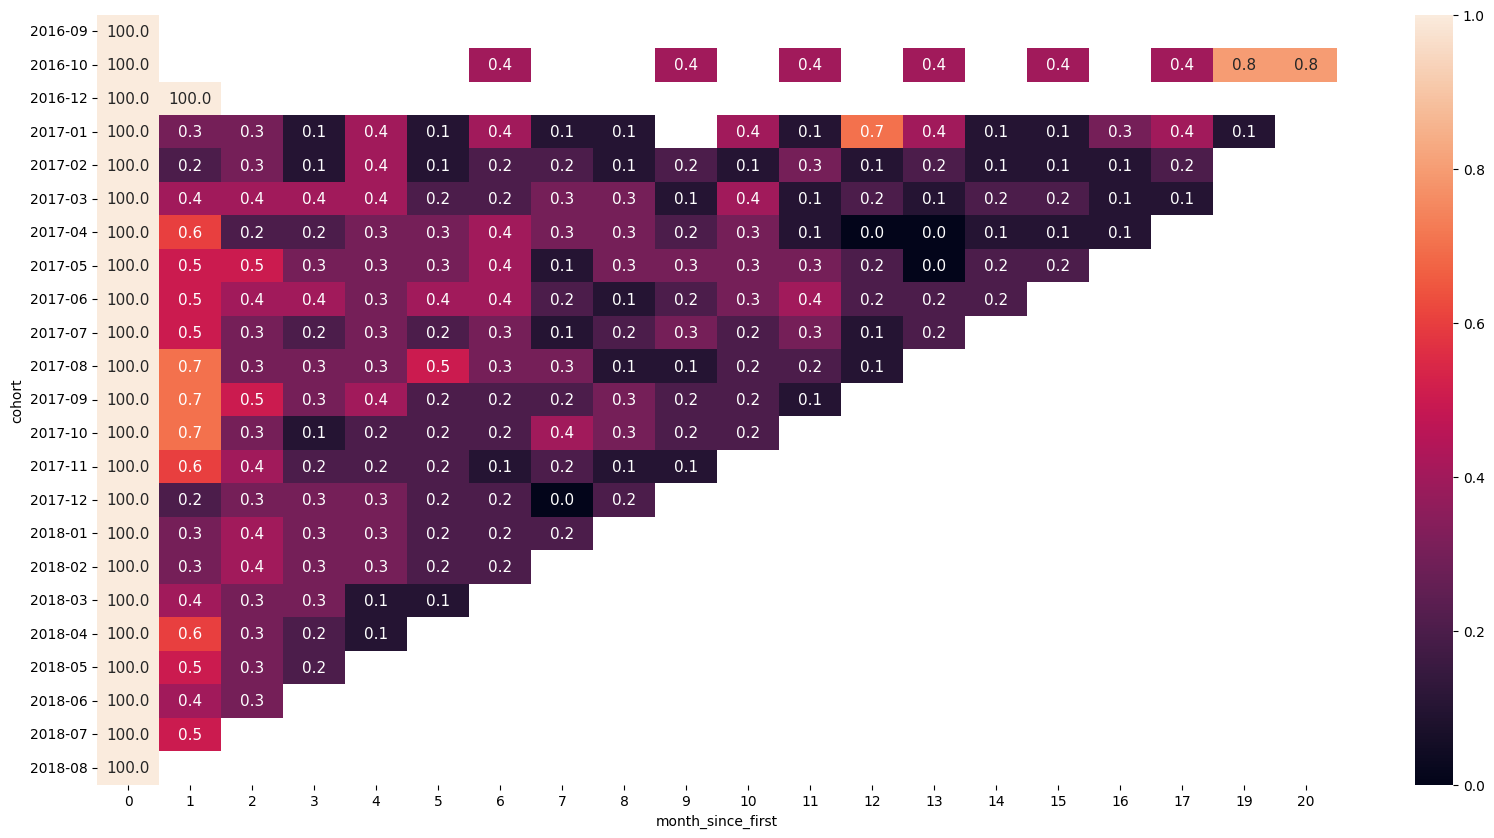

In [136]:
plt.figure(figsize=(20, 10))
sns.heatmap(cohort_matrix_pct, vmin=0, vmax=1,annot=True,fmt=".1f",annot_kws={"size": 11})

**Retention rate: ~3%** vs industry benchmark of 25–30% for e-commerce.  
Low retention = low LTV + high effective CAC = the business is paying to acquire customers it never sees again.

## Why Don't They Come Back? Checking Review Scores
If customers are unhappy, scores would drop. Let's check.

In [137]:
reviews = pd.read_csv('..\data\olist_order_reviews_dataset.csv')
reviews_df = pd.DataFrame(reviews)
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [138]:
reviews_agg = reviews_df.groupby('order_id')['review_score'].mean()
# reviews_agg.head()

In [139]:
orders_clean = pd.merge(orders_clean, reviews_agg, left_on='order_id', right_index=True, how='left')
orders_clean.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,price,freight_value,total_value,first_purchase_date,cohort,order_period,month_since_first,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71,2017-09-04 11:26:38,2017-09,2017-10,1,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46,2018-07-24 20:41:37,2018-07,2018-07,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12,2018-08-08 08:38:49,2018-08,2018-08,0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20,2017-11-18 19:28:06,2017-11,2017-11,0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62,2018-02-13 21:18:39,2018-02,2018-02,0,5.0


In [141]:
cohort_scores = orders_clean.groupby(['cohort'])['review_score'].mean()
print(cohort_scores)

cohort
2016-09    1.000000
2016-10    4.033088
2016-12    5.000000
2017-01    4.197028
2017-02    4.200473
2017-03    4.197333
2017-04    4.146347
2017-05    4.239274
2017-06    4.227727
2017-07    4.258433
2017-08    4.309473
2017-09    4.270784
2017-10    4.202346
2017-11    3.988829
2017-12    4.089503
2018-01    4.108305
2018-02    3.884821
2018-03    3.816461
2018-04    4.204869
2018-05    4.234188
2018-06    4.304993
2018-07    4.315947
2018-08    4.304027
Freq: M, Name: review_score, dtype: float64


**Scores are stable at 4.0–4.3/5 across all cohorts.**  
Customers aren't leaving because of a bad experience — they're leaving because there's no reason to return.  
This is **passive churn**: not angry, just indifferent.  
→ The fix is engagement (loyalty program, re-engagement emails), not product quality.